# Homework 5 — Collider bias in biking data

## tl;dr

| Question | Answer | Regression |
|---|---|---|
| Q1: Average coefficient of difficulty using X to predict Y | **A — −9.661** | Speed on difficulty, with an intercept |
| Q2: Average coefficient of difficulty using X and Z to predict Y | **B — −10.33** | Speed on difficulty and accident likelihood, with an intercept |

For the causal question in this example, **do not control for accident likelihood**.
Difficulty and speed both cause accident likelihood, making it a collider.
Adjusting for it makes the difficulty coefficient more negative. The simulation
below uses 1,000 independently generated datasets of 100,000 observations each.

## Context & Methods

Source: the questions and data-generation code supplied in `Homework_5.ipynb`
in the project folder. No Week 5 CSV is needed: the assignment defines how to
generate the data. X is trail difficulty (0–1), Y is biking speed (mph), and Z
is accident likelihood (0–1).

For each fresh dataset, generate the variables exactly as specified:

$$X\sim U(0,1),\qquad Y=\max(A-10X,0),\quad A\sim N(15,5^2),$$
$$Z=\min\{\max(0.03Y+0.4X+\varepsilon,0),1\},\quad
\varepsilon\sim N(0,0.3^2).$$

The normal draws are independent of X and of each other. Fit two ordinary
least-squares models to the same data within each repetition:

$$Q1:\quad Y=\alpha+\beta_X X+u,$$
$$Q2:\quad Y=\alpha+\beta_X X+\beta_Z Z+v.$$

### Key Assumptions

- Generate a new dataset for every repetition; this is a Monte Carlo experiment,
  not bootstrap resampling of one dataset.
- Both regressions include an intercept. Fit all 100,000 observations in each
  dataset; no training/test split is needed to answer a coefficient question.
- Preserve both clipping operations. The zero-speed floor makes the population
  Q1 linear slope slightly less negative than the −10 coefficient inside the
  untruncated speed formula.
- Use seed 42 for reproducibility. The generator is NumPy's `default_rng`; the
  prompt leaves its random seed unspecified, so individual simulations can differ.
- The intervals below describe Monte Carlo uncertainty in the **average fitted
  coefficient**, not a confidence interval from one 100,000-row regression.

If packages are missing: `%pip install numpy pandas scipy matplotlib scikit-learn`.

## Data

### 1. Set up the simulation

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
from sklearn.linear_model import LinearRegression
from IPython.display import display, Markdown

NUM_OBSERVATIONS = 100_000
NUM_REPETITIONS = 1_000
RANDOM_SEED = 42

pd.set_option('display.precision', 6)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110, 'font.size': 11,
    'axes.titlesize': 13, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'

def locate_source(filename):
    for folder in (Path.cwd(), *Path.cwd().parents):
        source = folder / filename
        if source.is_file():
            return source.resolve()
    raise FileNotFoundError(f'Cannot find {filename} above the working directory.')

SOURCE_PATH = locate_source('Homework_5.ipynb')
print('Source:', SOURCE_PATH.name)
print('SHA-256:', hashlib.sha256(SOURCE_PATH.read_bytes()).hexdigest())

Source: Homework_5.ipynb
SHA-256: 0e3c9ddb5478f65a0d97f410bcb68201db2ee06f555d3895c0fb2e767cfa608d


### 2. Generate data and define both OLS regressions

In [2]:
def generate_data(rng, num):
    difficulty = rng.uniform(0, 1, num)
    speed = np.maximum(rng.normal(15, 5, num) - difficulty * 10, 0)
    accident = np.minimum(np.maximum(
        0.03 * speed + 0.4 * difficulty + rng.normal(0, 0.3, num), 0), 1)
    return difficulty, speed, accident

def fit_both_models(difficulty, speed, accident):
    # Centering is equivalent to fitting an intercept in each regression.
    x = difficulty - difficulty.mean()
    y = speed - speed.mean()
    z = accident - accident.mean()
    xx, xy = x @ x, x @ y
    xz, zz, zy = x @ z, z @ z, z @ y

    # These are the exact OLS normal equations for the centered regressors.
    unadjusted_difficulty = xy / xx
    covariance_matrix = np.array([[xx, xz], [xz, zz]])
    adjusted_difficulty, adjusted_accident = np.linalg.solve(
        covariance_matrix, np.array([xy, zy]))
    return unadjusted_difficulty, adjusted_difficulty, adjusted_accident

## Results

### 3. Repeat the experiment with 1,000 fresh datasets

In [3]:
rng = np.random.default_rng(RANDOM_SEED)
coefficients = np.empty((NUM_REPETITIONS, 3))
example_data = None

for repetition in range(NUM_REPETITIONS):
    difficulty, speed, accident = generate_data(rng, NUM_OBSERVATIONS)
    coefficients[repetition] = fit_both_models(difficulty, speed, accident)
    if repetition == 0:
        example_data = pd.DataFrame({
            'difficulty': difficulty, 'speed': speed, 'accident': accident})

simulation_results = pd.DataFrame(coefficients, columns=[
    'Q1: difficulty only', 'Q2: controlling for accident', 'Q2: accident coefficient'])
simulation_results.index = pd.RangeIndex(1, NUM_REPETITIONS + 1, name='Repetition')
assert np.isfinite(simulation_results.to_numpy()).all()
print(f'Completed {NUM_REPETITIONS:,} independent datasets of {NUM_OBSERVATIONS:,} observations.')
print(f'Total generated observations: {NUM_REPETITIONS * NUM_OBSERVATIONS:,}')
display(simulation_results.head())

Completed 1,000 independent datasets of 100,000 observations.
Total generated observations: 100,000,000


,Q1: difficulty only,Q2: controlling for accident,Q2: accident coefficient
Repetition,,,
1,-9.731688,-10.362879,7.158227
2,-9.621212,-10.297622,7.062888
3,-9.685687,-10.339313,7.015005
4,-9.634745,-10.270771,7.040717
5,-9.678533,-10.296987,7.010175


### 4. Summarize the average difficulty coefficients

In [4]:
MODEL_NAMES = ['Q1: difficulty only', 'Q2: controlling for accident']
critical_t = stats.t.ppf(0.975, NUM_REPETITIONS - 1)
summary_rows = []
for name in MODEL_NAMES:
    draws = simulation_results[name]
    standard_deviation = draws.std(ddof=1)
    mc_se = standard_deviation / np.sqrt(NUM_REPETITIONS)
    summary_rows.append({
        'Model': name, 'Mean coefficient': draws.mean(),
        'SD across datasets': standard_deviation, 'Monte Carlo SE': mc_se,
        '95% MC interval lower': draws.mean() - critical_t * mc_se,
        '95% MC interval upper': draws.mean() + critical_t * mc_se,
    })
summary = pd.DataFrame(summary_rows)
display(summary)

paired_shift = (simulation_results[MODEL_NAMES[1]] - simulation_results[MODEL_NAMES[0]])
display(Markdown(
    f'The mean difficulty coefficient is **{summary.loc[0, "Mean coefficient"]:.6f}** '
    f'without accident likelihood and **{summary.loc[1, "Mean coefficient"]:.6f}** '
    f'when controlling for it. Adjustment changes the coefficient by '
    f'**{paired_shift.mean():.6f} mph per unit of difficulty**, on average.'
))

,Model,Mean coefficient,SD across datasets,Monte Carlo SE,95% MC interval lower,95% MC interval upper
0,Q1: difficulty only,-9.660587,0.050139,0.001586,-9.663699,-9.657476
1,Q2: controlling for accident,-10.325720,0.045669,0.001444,-10.328554,-10.322886


The mean difficulty coefficient is **-9.660587** without accident likelihood and **-10.325720** when controlling for it. Adjustment changes the coefficient by **-0.665132 mph per unit of difficulty**, on average.

### 5. Match each result to the quiz options

In [5]:
QUIZ_OPTIONS = {
    'Q1': {'A': -9.661, 'B': -9.243, 'C': -8.927, 'D': -10.14},
    'Q2': {'A': -11.23, 'B': -10.33, 'C': -10.85, 'D': -9.821},
}
answer_rows = []
option_rows = []
for question, model in zip(['Q1', 'Q2'], MODEL_NAMES):
    estimate = simulation_results[model].mean()
    choices = QUIZ_OPTIONS[question]
    closest = min(choices, key=lambda letter: abs(choices[letter] - estimate))
    answer_rows.append({'Question': question, 'Computed mean': estimate,
                        'Answer': closest, 'Closest listed value': choices[closest]})
    for letter, value in choices.items():
        option_rows.append({'Question': question, 'Option': letter, 'Listed value': value,
                           'Distance from computed mean': abs(value - estimate)})

answers = pd.DataFrame(answer_rows)
display(answers)
display(pd.DataFrame(option_rows))
assert answers['Answer'].tolist() == ['A', 'B']

,Question,Computed mean,Answer,Closest listed value
0,Q1,-9.660587,A,-9.661
1,Q2,-10.325720,B,-10.330


,Question,Option,Listed value,Distance from computed mean
0,Q1,A,-9.661,0.000413
1,Q1,B,-9.243,0.417587
2,Q1,C,-8.927,0.733587
3,Q1,D,-10.140,0.479413
4,Q2,A,-11.230,0.904280
5,Q2,B,-10.330,0.004280
6,Q2,C,-10.850,0.524280
7,Q2,D,-9.821,0.504720


### 6. View the distribution of fitted coefficients

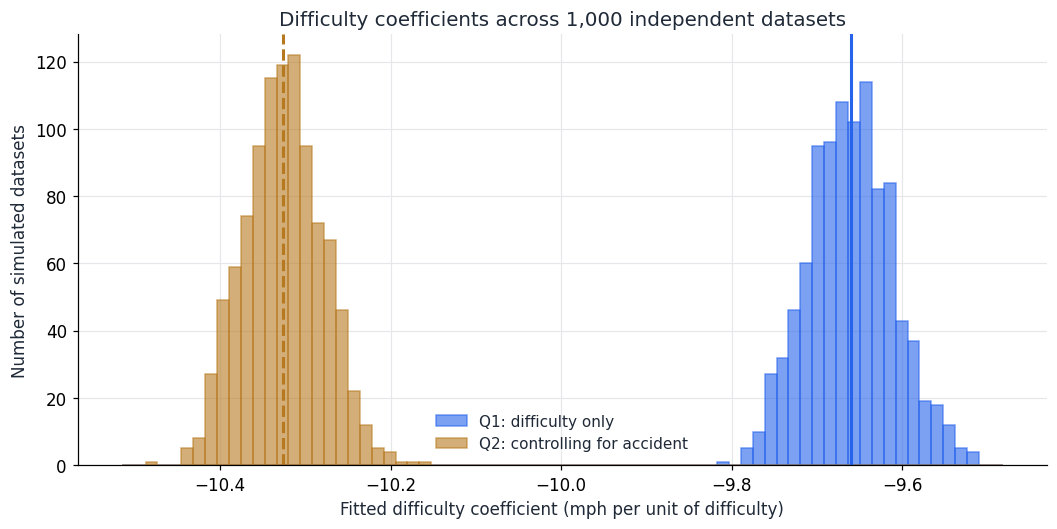

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.7), constrained_layout=True)
all_draws = simulation_results[MODEL_NAMES].to_numpy()
bins = np.linspace(all_draws.min() - .03, all_draws.max() + .03, 75)
for name, color, linestyle in [
    (MODEL_NAMES[0], BLUE, '-'), (MODEL_NAMES[1], GOLD, '--')
]:
    ax.hist(simulation_results[name], bins=bins, color=color, alpha=.6,
            edgecolor=color, label=name)
    ax.axvline(simulation_results[name].mean(), color=color, linestyle=linestyle, linewidth=2)
ax.set_xlabel('Fitted difficulty coefficient (mph per unit of difficulty)')
ax.set_ylabel('Number of simulated datasets')
ax.set_title('Difficulty coefficients across 1,000 independent datasets')
ax.legend(frameon=False, fontsize=10)
plt.show()

Both distributions are based on the same number of observations per dataset. The shift after adjustment is much larger than the ordinary variation across repetitions.

### 7. Check that the running averages stabilize

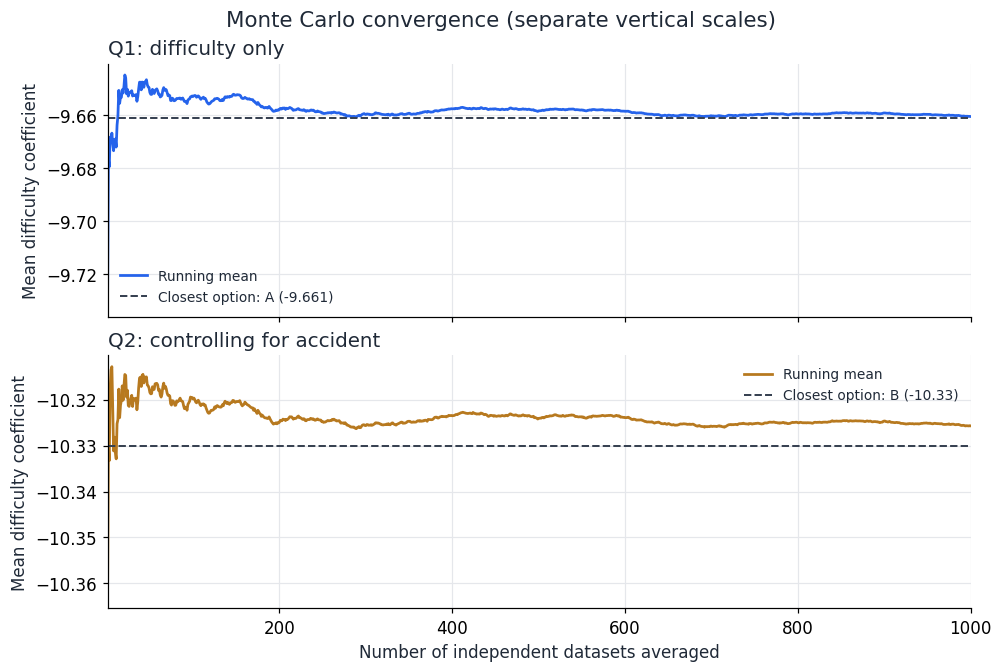

In [7]:
running_means = simulation_results[MODEL_NAMES].expanding().mean()
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True)
for ax, question, name, color in zip(axes, ['Q1', 'Q2'], MODEL_NAMES, [BLUE, GOLD]):
    answer = answers.loc[answers['Question'] == question].iloc[0]
    ax.plot(running_means.index, running_means[name], color=color, linewidth=1.8,
            label='Running mean')
    ax.axhline(answer['Closest listed value'], color=DARK, linestyle='--', linewidth=1.3,
               label=f'Closest option: {answer["Answer"]} ({answer["Closest listed value"]:g})')
    ax.set_ylabel('Mean difficulty coefficient')
    ax.set_title(name, loc='left')
    ax.legend(frameon=False, fontsize=9)
    ax.set_xlim(1, NUM_REPETITIONS)
axes[-1].set_xlabel('Number of independent datasets averaged')
fig.suptitle('Monte Carlo convergence (separate vertical scales)', fontsize=14)
plt.show()

### 8. Verify the regressions and the zero-speed floor

The original speed formula has a −10 term, but clipping negative speeds to zero
changes the observed conditional mean. If $m(x)=15-10x$, then

$$E[Y\mid X=x]=m(x)\Phi(m(x)/5)+5\phi(m(x)/5).$$

Since X is uniform on [0, 1], its population linear-projection slope is
$12\int_0^1(x-0.5)E[Y\mid X=x]dx$. This provides a numerical benchmark
independent of the simulation. Also verify both regression implementations
against scikit-learn on the first dataset.

In [8]:
simple_check = LinearRegression().fit(example_data[['difficulty']], example_data['speed'])
adjusted_check = LinearRegression().fit(
    example_data[['difficulty', 'accident']], example_data['speed'])
np.testing.assert_allclose(simple_check.coef_[0], coefficients[0, 0], rtol=1e-11, atol=1e-11)
np.testing.assert_allclose(adjusted_check.coef_, coefficients[0, 1:], rtol=1e-11, atol=1e-11)

assert example_data['difficulty'].between(0, 1).all()
assert example_data['speed'].ge(0).all()
assert example_data['accident'].between(0, 1).all()

def expected_speed(x):
    conditional_location = 15 - 10 * x
    return (conditional_location * stats.norm.cdf(conditional_location / 5)
            + 5 * stats.norm.pdf(conditional_location / 5))

population_slope = 12 * quad(lambda x: (x - .5) * expected_speed(x), 0, 1)[0]
display(pd.DataFrame({
    'Quantity': ['Q1 population linear-projection slope', 'Q1 simulated mean coefficient',
                'Simulation minus population benchmark'],
    'Value': [population_slope, simulation_results[MODEL_NAMES[0]].mean(),
              simulation_results[MODEL_NAMES[0]].mean() - population_slope],
}))
print('Checks passed: both OLS implementations match scikit-learn; generated values respect their bounds.')

,Quantity,Value
0,Q1 population linear-projection slope,-9.661269
1,Q1 simulated mean coefficient,-9.660587
2,Simulation minus population benchmark,0.000681


Checks passed: both OLS implementations match scikit-learn; generated values respect their bounds.


## Takeaways

**Q1: A — −9.661. Q2: B — −10.33.**

The causal structure is $X\rightarrow Y$, together with $X\rightarrow Z\leftarrow Y$.
Accident likelihood is a common effect of difficulty and speed, not a confounder
of their relationship. Holding accident likelihood fixed creates an additional
negative association: among observations with the same accident likelihood,
higher difficulty tends to be accompanied by lower speed. The regression then mixes this
selection effect with the causal relationship we wanted to study.

For estimating difficulty's total effect on speed in this data-generating
process, omit accident likelihood. Difficulty is generated independently of
the speed noise, so there is no confounding here that controlling for accident
likelihood would solve. The unadjusted OLS slope summarizes the causal mean
relationship linearly, while the zero-speed floor explains why it is not exactly −10.

### Reproducibility

In [9]:
print('Python:', platform.python_version())
for package in ['numpy', 'pandas', 'scipy', 'matplotlib', 'scikit-learn']:
    print(f'{package}: {importlib.metadata.version(package)}')
print(f'Seed={RANDOM_SEED}; datasets={NUM_REPETITIONS}; rows per dataset={NUM_OBSERVATIONS}')

Python: 3.13.5
numpy: 2.4.1
pandas: 3.0.0
scipy: 1.17.0
matplotlib: 3.10.8
scikit-learn: 1.8.0
Seed=42; datasets=1000; rows per dataset=100000
